# 🏠 House Price Prediction using Linear Regression

## Supervised Learning
- Seaborn

Now we will start **Machine Learning** with the first supervised learning algorithm:

# Linear Regression

## Project Goal

We will build a machine learning model that predicts the **price of a house** using features such as:

- house area
- number of bedrooms
- number of bathrooms
- house age
- distance from city center
- location category

## What students will learn

By the end of this notebook, students will understand:

1. What supervised learning means
2. Difference between features and target
3. How to prepare data for machine learning
4. How to split data into training and testing sets
5. How Linear Regression works
6. How to train a model
7. How to make predictions
8. How to evaluate a regression model
9. How to interpret model results
10. How to save a trained model


# ✅ Complete Project Steps

We will perform the project in these steps:

| Step | Task |
|---|---|
| 1 | Import required libraries |
| 2 | Create / load house price dataset |
| 3 | Understand the dataset |
| 4 | Exploratory Data Analysis |
| 5 | Check missing values |
| 6 | Handle categorical features |
| 7 | Select features and target |
| 8 | Split data into training and testing sets |
| 9 | Train Linear Regression model |
| 10 | Make predictions |
| 11 | Evaluate model performance |
| 12 | Visualize actual vs predicted prices |
| 13 | Interpret coefficients |
| 14 | Predict price for a new house |
| 15 | Save model for future use |


# 1. Import Required Libraries

We use:

- **NumPy** for numerical operations
- **Pandas** for data handling
- **Matplotlib** and **Seaborn** for visualization
- **Scikit-learn** for machine learning
- **Joblib** for saving the trained model


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


# 2. Create a House Price Dataset

In real projects, you usually load data from a CSV file:

```python
df = pd.read_csv("house_prices.csv")
```

For teaching purposes, this notebook creates a realistic synthetic dataset.

This is useful because every student can run the notebook without downloading anything.


In [26]:
# For reproducibility
np.random.seed(42)

# Number of houses
n = 1000

# Create features
area_sqft = np.random.randint(600, 5000, n)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
house_age = np.random.randint(0, 40, n)
distance_city_km = np.round(np.random.uniform(1, 35, n), 2)

locations = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    size=n,
    p=[0.45, 0.35, 0.20]
)

# Location effect on price
location_effect = {
    "Urban": 35000,
    "Suburban": 20000,
    "Rural": 5000
}

# Create price using a realistic formula + random noise
price = (
    area_sqft * 120
    + bedrooms * 15000
    + bathrooms * 10000
    - house_age * 1800
    - distance_city_km * 2500
    + np.array([location_effect[loc] for loc in locations])
    + np.random.normal(0, 25000, n)
)

# Convert price to positive integer
price = np.round(price).astype(int)

# Create DataFrame
df = pd.DataFrame({
    "area_sqft": area_sqft,
    "bedrooms": bedrooms,
    "bathrooms": bathrooms,
    "house_age": house_age,
    "distance_city_km": distance_city_km,
    "location": locations,
    "price": price
})

df.head()


,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,location,price
0,1460,3,4,39,25.59,Suburban,192914
1,4372,1,1,17,7.82,Urban,574967
2,3692,6,3,19,7.92,Rural,489833
3,1066,3,2,5,1.34,Urban,235576
4,4044,2,1,11,15.87,Rural,427519


# 3. Understand the Dataset

Before building a model, always understand the data.

We will check:

- number of rows and columns
- column names
- data types
- summary statistics


In [27]:
# Shape of dataset
df.shape


(1000, 7)

In [28]:
# Column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         1000 non-null   int32  
 1   bedrooms          1000 non-null   int32  
 2   bathrooms         1000 non-null   int32  
 3   house_age         1000 non-null   int32  
 4   distance_city_km  1000 non-null   float64
 5   location          1000 non-null   object 
 6   price             1000 non-null   int32  
dtypes: float64(1), int32(5), object(1)
memory usage: 35.3+ KB


In [29]:
# Summary statistics for numerical columns
df.describe()


,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,price
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2854.807000,3.458000,2.521000,19.87300,18.248330,361672.321000
std,1221.734084,1.704447,1.136156,11.51501,9.671786,152907.315008
min,603.000000,1.000000,1.000000,0.00000,1.070000,-9141.000000
25%,1816.250000,2.000000,2.000000,10.00000,10.080000,238874.250000
50%,2871.500000,3.000000,2.000000,20.00000,18.520000,368540.000000
75%,3881.500000,5.000000,4.000000,30.00000,26.597500,484654.500000
max,4989.000000,6.000000,4.000000,39.00000,34.980000,713118.000000


# 4. Exploratory Data Analysis

EDA helps us understand relationships in the data.

For Linear Regression, we especially want to see how numerical features relate to the target column **price**.


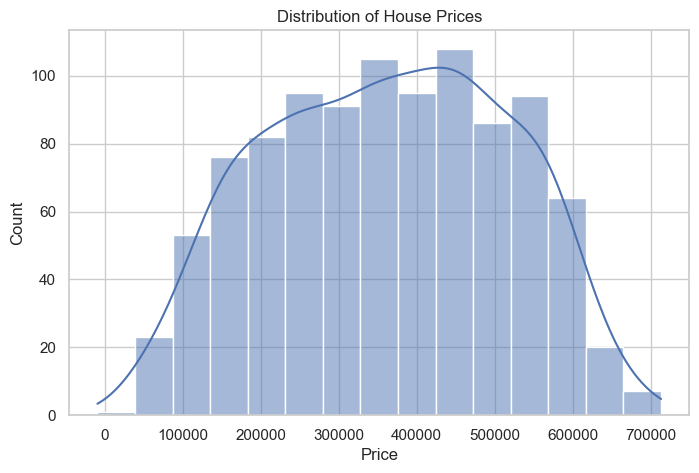

In [30]:
# Distribution of house prices
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


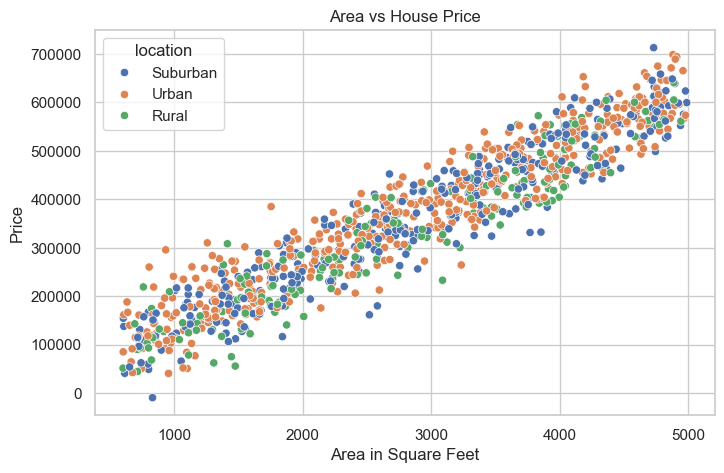

In [31]:
# Scatter plot: area vs price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="area_sqft", y="price", hue="location")
plt.title("Area vs House Price")
plt.xlabel("Area in Square Feet")
plt.ylabel("Price")
plt.show()


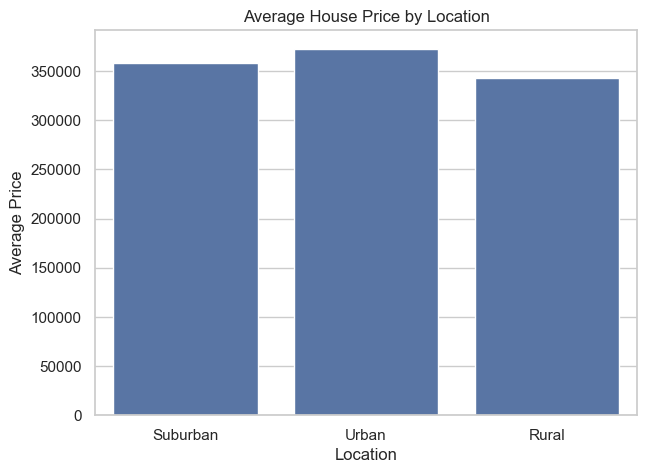

In [8]:
# Average price by location
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="location", y="price", errorbar=None)
plt.title("Average House Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.show()


In [32]:
# Correlation between numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Numerical columns correlation:" , numeric_df.corr())

# plt.figure(figsize=(9, 6))
# sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Correlation Heatmap")
# plt.show()


Numerical columns correlation:                   distance_city_km
distance_city_km               1.0


# 5. Check Missing Values

Missing values can create errors during model training.

Always check missing values before training a machine learning model.


In [33]:
df.isnull().sum()


area_sqft           0
bedrooms            0
bathrooms           0
house_age           0
distance_city_km    0
location            0
price               0
dtype: int64

Our synthetic dataset has no missing values.

In a real project, if missing values exist, you can handle them like this:

```python
df["area_sqft"] = df["area_sqft"].fillna(df["area_sqft"].median())
df["location"] = df["location"].fillna(df["location"].mode()[0])
```


# 6. Handle Categorical Features

Machine learning models cannot directly understand text categories such as:

- Urban
- Suburban
- Rural

So we convert categorical columns into numerical format using **One-Hot Encoding**.

Example:

| location | location_Suburban | location_Urban |
|---|---:|---:|
| Rural | 0 | 0 |
| Suburban | 1 | 0 |
| Urban | 0 | 1 |

We use `drop_first=True` to avoid duplicate information.


In [34]:
df_encoded = pd.get_dummies(df, columns=["location"], drop_first=True)

df_encoded.head()


,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,price,location_Suburban,location_Urban
0,1460,3,4,39,25.59,192914,True,False
1,4372,1,1,17,7.82,574967,False,True
2,3692,6,3,19,7.92,489833,False,False
3,1066,3,2,5,1.34,235576,False,True
4,4044,2,1,11,15.87,427519,False,False


# 7. Select Features and Target

In supervised learning:

- **Features / X** are input columns
- **Target / y** is the column we want to predict

Here:

- X = house details
- y = house price


In [35]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()


Features shape: (1000, 7)
Target shape: (1000,)


,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,location_Suburban,location_Urban
0,1460,3,4,39,25.59,True,False
1,4372,1,1,17,7.82,False,True
2,3692,6,3,19,7.92,False,False
3,1066,3,2,5,1.34,False,True
4,4044,2,1,11,15.87,False,False


In [36]:
y.head()

0    192914
1    574967
2    489833
3    235576
4    427519
Name: price, dtype: int32

# 8. Split Data into Training and Testing Sets

We split the data into two parts:

## Training Data
Used to train the model.

## Testing Data
Used to check how well the model performs on unseen data.

Common split:

- 80% training
- 20% testing


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (800, 7)
X_test shape: (200, 7)
y_train shape: (800,)
y_test shape: (200,)


# 9. Train the Linear Regression Model

Linear Regression tries to learn this type of relationship:

```text
price = coefficient_1 × area + coefficient_2 × bedrooms + ... + intercept
```

The model learns the best coefficients from the training data.


In [38]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")


Model training completed!


# 10. Make Predictions

Now we use the trained model to predict house prices for the test data.


In [39]:
y_pred = model.predict(X_test)

# Show first 10 predictions
predictions_df = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": np.round(y_pred[:10]).astype(int)
})

predictions_df


,Actual Price,Predicted Price
0,145843,182441
1,127394,169805
2,376300,382518
3,193195,216071
4,370729,367754
5,342840,363880
6,463686,450450
7,494639,501031
8,249183,213682
9,215679,223591


# 11. Evaluate Model Performance

For regression problems, common evaluation metrics are:

## Mean Absolute Error
Average absolute difference between actual and predicted prices.

## Mean Squared Error
Average squared difference between actual and predicted prices.

## Root Mean Squared Error
Square root of MSE. It is easier to understand because it has the same unit as the target.

## R² Score
Shows how much variation in the target is explained by the model.

R² score ranges from 0 to 1 in many practical cases.

- closer to 1 = better model
- closer to 0 = weaker model


In [40]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print(f"Mean Absolute Error  : {mae:,.2f}")
print(f"Mean Squared Error   : {mse:,.2f}")
print(f"Root Mean Squared Error: {rmse:,.2f}")
print(f"R2 Score             : {r2:.4f}")


Model Evaluation Results
------------------------
Mean Absolute Error  : 17,951.63
Mean Squared Error   : 508,048,860.05
Root Mean Squared Error: 22,539.94
R2 Score             : 0.9794


Yeh results show kar rahe hain ke hamara model **kaafi acha perform** kar raha hai.

**MAE = 17,951** ka matlab hai model average par house price mein almost **18k ka error** kar raha hai.
**RMSE = 22,539** batata hai ke kuch predictions mein error thora zyada bhi ho sakta hai.
**MSE** error ka squared version hota hai, is liye iska number bohat bara hota hai.
**R² Score = 0.9794** ka matlab hai model data ka almost **97.94% pattern samajh chuka hai**.
Simple words mein: model house price predict karne mein **very accurate** hai, lekin perfect nahi, thora error naturally hota hai.


# 12. Visualize Actual vs Predicted Prices

A good model should have predicted values close to actual values.

In the scatter plot below:

- x-axis = actual prices
- y-axis = predicted prices

If points are close to the diagonal line, predictions are good.


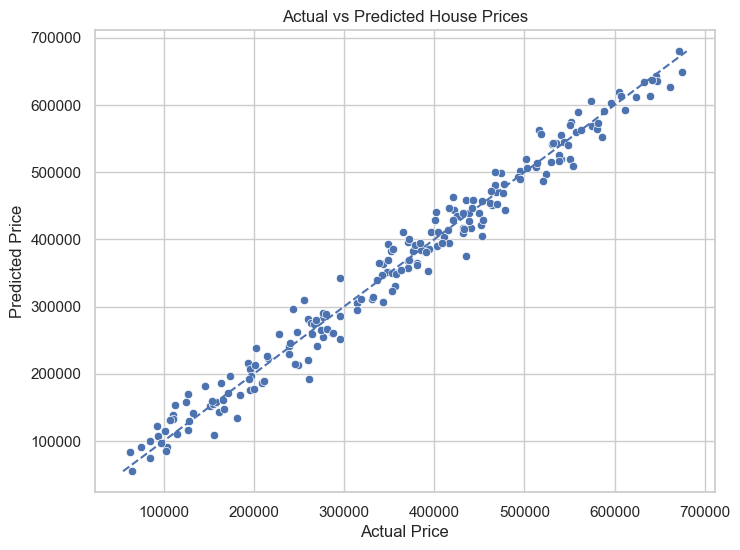

In [41]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

# Perfect prediction line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.show()


# 13. Residual Analysis

Residual means:

```text
Residual = Actual Price - Predicted Price
```

Residual analysis helps us check model errors.


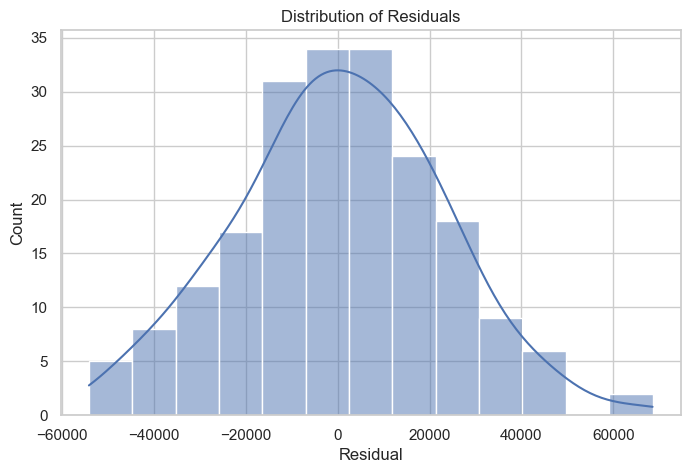

In [42]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()


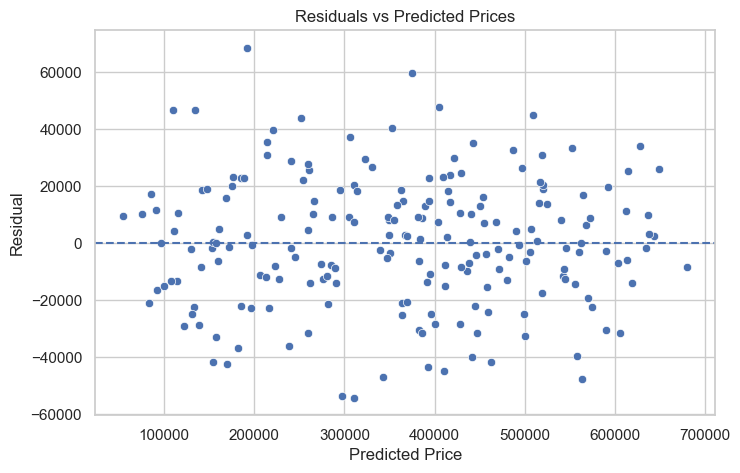

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.title("Residuals vs Predicted Prices")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.show()


# 15. Predict Price for a New House

Now we will make a prediction for one new house.

Important: The new house data must have the same columns as training data.


In [43]:
# Check feature columns
X.columns


Index(['area_sqft', 'bedrooms', 'bathrooms', 'house_age', 'distance_city_km',
       'location_Suburban', 'location_Urban'],
      dtype='object')

In [22]:
new_house = pd.DataFrame({
    "area_sqft": [2500],
    "bedrooms": [4],
    "bathrooms": [3],
    "house_age": [5],
    "distance_city_km": [8.5],
    "location_Suburban": [0],
    "location_Urban": [1]
})

predicted_price = model.predict(new_house)

print(f"Predicted House Price: {predicted_price[0]:,.0f}")


Predicted House Price: 394,700


# 16. Save the Trained Model

After training a model, we can save it and use it later without training again.

We use `joblib` to save the model.


In [23]:
joblib.dump(model, "house_price_linear_regression_model.pkl")

print("Model saved successfully!")


Model saved successfully!


# 17. Load the Saved Model

This is how you load the saved model later.


In [24]:
loaded_model = joblib.load("house_price_linear_regression_model.pkl")

loaded_prediction = loaded_model.predict(new_house)

print(f"Prediction from loaded model: {loaded_prediction[0]:,.0f}")


Prediction from loaded model: 394,700


# 18. Complete Machine Learning Pipeline Summary

This is the full flow students should remember:

```text
Problem Definition
        ↓
Load Data
        ↓
Understand Data
        ↓
EDA
        ↓
Clean Data
        ↓
Encode Categorical Features
        ↓
Select X and y
        ↓
Train-Test Split
        ↓
Train Model
        ↓
Predict
        ↓
Evaluate
        ↓
Improve Model
        ↓
Save Model
```


# Student Practice Tasks

Give these tasks to students after completing the notebook:

## Task 1
Change the number of rows in the dataset from 1000 to 2000 and retrain the model.

## Task 2
Add a new feature called `garage_size`.

## Task 3
Create a new visualization showing `house_age` vs `price`.

## Task 4
Predict the price of 5 new houses.

## Task 5
Compare model performance after removing the `distance_city_km` column.

## Task 6
Explain the meaning of each coefficient in simple English.


# Final Conclusion

In this project, we successfully built a **House Price Prediction Model** using **Linear Regression**.

We learned:

- how supervised learning works
- how to prepare features and target
- how to train a Linear Regression model
- how to evaluate regression performance
- how to interpret model coefficients
- how to save and reuse a trained model

This is the best first project before teaching Logistic Regression, Decision Trees, Random Forest, and other supervised learning algorithms.
